# Function 5 – Next Evaluation (Week 9)

### What changed this week
- Switched to `bayesian_optimization_exploitative_2.py`.
- Use a noise-aware GP with local trust-region exploitation around the incumbent.
- Increase duplicate-merging tolerance to `5e-3` for near-repeated Function 5 evaluations.
- Keep the proposed output as the raw GP predicted mean.

Load all observed data (including Week 8), identify the current maximum (incumbent), run local exploitative Bayesian Optimization (beta=0), and save the suggested next point.

In [2]:
import numpy as np

def validate_progress(y_observed, function_name=None, recent_k=3, tol_frac=0.01, min_improve_frac=0.05):
    """
    Deterministic progress check for maximizing an objective (higher is better).

    Args:
        y_observed: list/array of observed y values.
        recent_k: how many recent points to consider.
        tol_frac: how close recent best must be to best overall to call it "near best"
                  (fraction of |best_overall|, handles negatives safely).
        min_improve_frac: if near best, require at least this fractional improvement vs previous point
                          to avoid calling it plateau.

    Returns:
        status: 'improving' | 'plateau' | 'stuck' | 'insufficient_data'
        message: explanation
        flag: True if concerning
    """
    y = np.asarray(y_observed, dtype=float)
    n = len(y)

    if n < recent_k + 1:
        return "insufficient_data", "Not enough data to validate", False

    recent = y[-recent_k:]
    best_overall = float(np.max(y))
    best_recent = float(np.max(recent))

    scale = max(abs(best_overall), 1e-12)
    close_tol = tol_frac * scale
    near_best = (best_overall - best_recent) <= close_tol

    prev = float(y[-2])
    last = float(y[-1])
    step_scale = max(abs(prev), 1e-12)
    step_improve_frac = (last - prev) / step_scale

    if near_best:
        if step_improve_frac >= min_improve_frac:
            return "improving", f"Near best and still improving. Best={best_overall:.6f}, last={last:.6f}", False
        else:
            return "plateau", f"Near best but improvements are small. Best={best_overall:.6f}, last={last:.6f}", True

    recent_trend = float(recent[-1] - recent[0])
    if recent_trend > 0:
        return "improving", f"Recent trend is positive, moving toward best={best_overall:.6f}", False
    else:
        return "stuck", f"Recent trend is negative and not near best. Best={best_overall:.6f}, recent_best={best_recent:.6f}", True


In [ ]:
import numpy as np
from pathlib import Path

import sys
sys.path.append('../..')

from scripts.utils.data_utils import (
    load_initial_data,
    load_week1_data,
    load_week2_data,
    load_week3_data,
    load_week4_data,
    _load_latest_week_data,
    plot_tsne_with_distribution,
)

# Week 9 changes: use the local, noise-aware exploitative BO variant
from scripts.bayesian_optimisation.bayesian_optimization_exploitative_2 import SimpleBayesianOptimization

base_dir = Path('../../data/initial_data')
week1_dir = Path('../../data/week1')
week2_dir = Path('../../data/week2')
week3_dir = Path('../../data/week3')
week4_dir = Path('../../data/week4')
week5_dir = Path('../../data/week5')
week6_dir = Path('../../data/week6')
week7_dir = Path('../../data/week7')
week8_dir = Path('../../data/week8')

initial_data = load_initial_data(base_dir)
week1_data = load_week1_data(week1_dir)
week2_data = load_week2_data(week2_dir)
week3_data = load_week3_data(week3_dir)
week4_data = load_week4_data(week4_dir)
week5_data = _load_latest_week_data(week5_dir, 'Week 5')
week6_data = _load_latest_week_data(week6_dir, 'Week 6')
week7_data = _load_latest_week_data(week7_dir, 'Week 7')
week8_data = _load_latest_week_data(week8_dir, 'Week 8')

function_name = 'function_5'
original_inputs = initial_data[function_name]['inputs']
original_outputs = initial_data[function_name]['outputs']
week1_input = week1_data[function_name]['input']
week1_output = week1_data[function_name]['output']
week2_input = week2_data[function_name]['input']
week2_output = week2_data[function_name]['output']
week3_input = week3_data[function_name]['input']
week3_output = week3_data[function_name]['output']
week4_input = week4_data[function_name]['input']
week4_output = week4_data[function_name]['output']
week5_input = week5_data[function_name]['input']
week5_output = week5_data[function_name]['output']
week6_input = week6_data[function_name]['input']
week6_output = week6_data[function_name]['output']
week7_input = week7_data[function_name]['input']
week7_output = week7_data[function_name]['output']
week8_input = week8_data[function_name]['input']
week8_output = week8_data[function_name]['output']

X_observed = np.vstack([
    original_inputs,
    week1_input.reshape(1, -1),
    week2_input.reshape(1, -1),
    week3_input.reshape(1, -1),
    week4_input.reshape(1, -1),
    week5_input.reshape(1, -1),
    week6_input.reshape(1, -1),
    week7_input.reshape(1, -1),
    week8_input.reshape(1, -1),
])
y_observed = np.concatenate([
    original_outputs,
    np.array([week1_output, week2_output, week3_output, week4_output, week5_output, week6_output, week7_output, week8_output]),
])

best_idx = np.argmax(y_observed)
incumbent_input = X_observed[best_idx]
incumbent_output = y_observed[best_idx]

print('=' * 60)
print('FUNCTION 5 – CURRENT MAXIMUM (INCUMBENT)')
print('=' * 60)
print(f'Incumbent input (best-performing configuration): {incumbent_input}')
print(f'Incumbent output (observed maximum):            {incumbent_output:.6f}')
print(f'Number of observations:                         {len(y_observed)}')

# Progress validation
status, message, flag = validate_progress(y_observed, function_name)
print(f"\n{'⚠️ ' if flag else '✓ '}PROGRESS STATUS: {status.upper()}")
print(f"  {message}")
print('=' * 60)

FUNCTION 5 – CURRENT MAXIMUM (INCUMBENT)
Incumbent input (best-performing configuration): [0.937239 0.959791 0.960767 0.818897]
Incumbent output (observed maximum):            4219.157963
Number of observations:                         28

✓ PROGRESS STATUS: IMPROVING
  Recent trend is positive, moving toward best=4219.157963


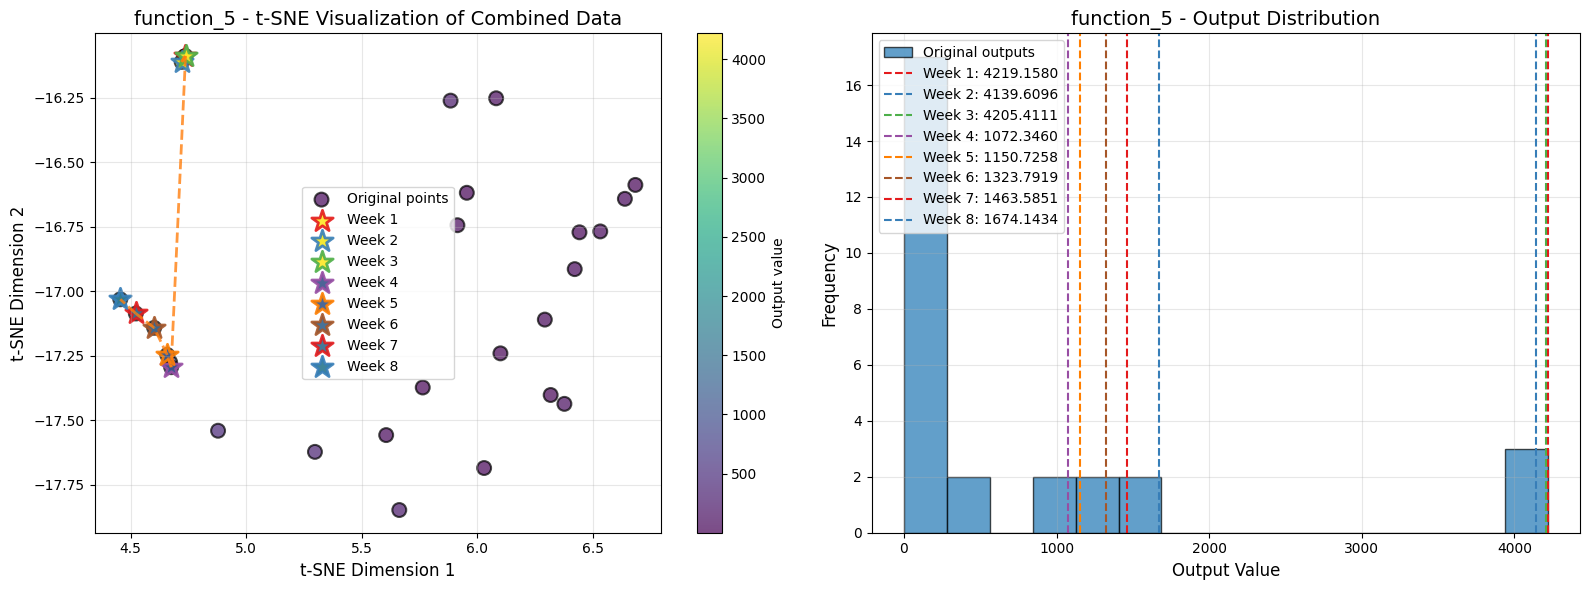

In [4]:
# Visualise past results: show all week 1–7 points before deciding on next evaluation
plot_tsne_with_distribution(
    X_observed, y_observed,
    week8_input, week8_output,
    function_name,
    weekly_points=[
        (week1_input, week1_output, "Week 1"),
        (week2_input, week2_output, "Week 2"),
        (week3_input, week3_output, "Week 3"),
        (week4_input, week4_output, "Week 4"),
        (week5_input, week5_output, "Week 5"),
        (week6_input, week6_output, "Week 6"),
        (week7_input, week7_output, "Week 7"),
        (week8_input, week8_output, "Week 8"),
    ],
    connect_points=True,
    connect_color="tab:orange",
    random_state=42
)

In [5]:
# Run local exploitative BO (beta=0) and suggest the next point near the incumbent
n_dims = X_observed.shape[1]
bounds = [[0.0, 1.0]] * n_dims

# Week 9 changes:
# - use the local/noise-aware exploitative GP
# - merge near-duplicate inputs with a slightly larger tolerance for Function 5
# - keep the search anchored to the incumbent region
bo = SimpleBayesianOptimization(
    bounds=bounds,
    n_initial=0,
    random_state=42,
    aggregate_tol=5e-3,
    trust_region_scale=0.075,
    local_topk=1,
)
bo.fit(X_observed, y_observed)
next_point = bo.suggest_next_point(beta=0.0)
pred_mean, pred_std = bo.predict(next_point.reshape(1, -1))
expected_value = float(pred_mean[0])
expected_std = float(pred_std[0])
distance_to_best = float(np.linalg.norm(next_point - incumbent_input))

formatted_point = '-'.join([f'{x:.6f}' for x in next_point])

print('=' * 60)
print('FUNCTION 5 – LOCAL EXPLOITATIVE BO SUGGESTION (beta=0)')
print('=' * 60)
print(f"Raw points used: {bo.fit_summary['raw_points']}")
print(f"Aggregated model points: {bo.fit_summary['model_points']}")
print(f"Merged clusters: {bo.fit_summary['merged_clusters']}")
print(f"Fitted kernel: {bo.fit_summary['kernel']}")
print(f'Suggested next point: {formatted_point}')
print(f'Predicted mean (table Output value): {expected_value:.6f}')
print(f'Predicted std: {expected_std:.6f}')
print(f'Distance to incumbent input: {distance_to_best:.6f}')
if flag:
    print(f"\nWARNING: {message}")
    print("Check whether the function is still plateauing near the incumbent.")
print('=' * 60)

FUNCTION 5 – LOCAL EXPLOITATIVE BO SUGGESTION (beta=0)
Raw points used: 28
Aggregated model points: 26
Merged clusters: 2
Fitted kernel: 1.45**2 * RBF(length_scale=0.71) + WhiteKernel(noise_level=0.00163)
Suggested next point: 1.000000-1.000000-1.000000-0.893494
Predicted mean (table Output value): 4787.681699
Predicted std: 156.729888
Distance to incumbent input: 0.112515


## Approach for Next Evaluation (Function 5 – Local Exploitative BO)

For the next evaluation, we use **local exploitative Bayesian Optimization**: a noise-aware GP is fit to the observed data, and the next point is chosen by **maximising the GP posterior mean locally around the incumbent**.

---

### Why this approach

Function 5 appears mostly smooth, but it also contains near-repeated evaluations around strong regions. Under that assumption:

- The GP surrogate should model a small amount of observation noise instead of forcing a perfectly noiseless fit.
- **Exploitation** (beta=0) is still appropriate because the best region is already clear.
- A local trust region prevents the optimizer from drifting to unstable global spikes.
- The next point is chosen to refine predicted performance near the incumbent.

---

### What we are doing

We **evaluate the objective at the BO-suggested point** above. This keeps the search exploitative while using a more stable surrogate than the earlier global mean-only BO.

In [6]:
# Save to results/ in the same format, with extra diagnostics for the local BO fit
import json

result = {
    "function_name": function_name,
    "next_point": next_point.tolist(),
    "formatted": formatted_point,
    "method": "bayesian_optimization_exploitative_local_noise_aware",
    "acquisition": "mean_local_trust_region",
    "expected_value": expected_value,
    "expected_std": expected_std,
    "distance_to_incumbent": distance_to_best,
    "raw_points": bo.fit_summary['raw_points'],
    "model_points": bo.fit_summary['model_points'],
    "merged_clusters": bo.fit_summary['merged_clusters'],
    "kernel": bo.fit_summary['kernel'],
    "validation_status": status,
    "validation_message": message,
    "validation_flag": flag,
}
Path("results").mkdir(exist_ok=True)
output_path = Path("results/function5_next_point.json")
with open(output_path, "w") as f:
    json.dump(result, f, indent=2)

print('Next evaluation point (BO suggestion):', formatted_point)
print('Input vector:', next_point)
print(f'Predicted mean: {expected_value:.6f}')
print(f'Predicted std: {expected_std:.6f}')
print(f'Distance to incumbent: {distance_to_best:.6f}')
print(f"\nResult saved to: {output_path}")

Next evaluation point (BO suggestion): 1.000000-1.000000-1.000000-0.893494
Input vector: [1.       1.       1.       0.893494]
Predicted mean: 4787.681699
Predicted std: 156.729888
Distance to incumbent: 0.112515

Result saved to: results/function5_next_point.json


### Inputs/Outputs comparison table (Function 5)

Source, Input number, Output value, Distance to maximum input, Summary of progress. Proposed week 9 row uses the local BO-suggested next point and the raw GP predicted mean as estimated output.

In [8]:
import importlib
import scripts.utils.distance_utils as distance_utils
importlib.reload(distance_utils)
from scripts.utils.distance_utils import make_inputs_outputs_table

n_initial = original_inputs.shape[0]
table = make_inputs_outputs_table(
    X_observed, y_observed, n_initial,
    x_proposed=next_point,
    y_proposed=float(expected_value),
)
display(table)

,Source,Input number,Output value,Distance to maximum input,Summary of progress
0,initial,1,64.443440,1.301488,Initial
1,initial,2,18.301380,0.717084,Initial
2,initial,3,0.112940,1.132268,Initial
3,initial,4,4.210898,0.912781,Initial
4,initial,5,258.370525,0.828509,Initial
5,initial,6,78.434389,0.923270,Initial
6,initial,7,57.571537,0.799012,Initial
7,initial,8,109.571876,1.257021,Initial
8,initial,9,8.847992,1.047738,Initial
9,initial,10,233.223610,1.039159,Initial
